In [1]:
import seaborn as sns

c:\Users\soumi\AppData\Local\Programs\Python\Python312\Lib\site-packages\seaborn\_statistics.py:32: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.4)
  from scipy.stats import gaussian_kde


In [2]:
df = sns.load_dataset("titanic")

In [3]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# checking for missing values
df.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [6]:
# delete the rows
df.shape

(891, 15)

In [ ]:
df.dropna().shape #not a good idea as we are losing a lot of data

(182, 15)

In [9]:
#column wise deletion
df.dropna(axis=1) # we are losing the age column which is important for our analysis

,survived,pclass,sex,sibsp,parch,fare,class,who,adult_male,alive,alone
0,0,3,male,1,0,7.2500,Third,man,True,no,False
1,1,1,female,1,0,71.2833,First,woman,False,yes,False
2,1,3,female,0,0,7.9250,Third,woman,False,yes,True
3,1,1,female,1,0,53.1000,First,woman,False,yes,False
4,0,3,male,0,0,8.0500,Third,man,True,no,True
...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,0,0,13.0000,Second,man,True,no,True
887,1,1,female,0,0,30.0000,First,woman,False,yes,True
888,0,3,female,1,2,23.4500,Third,woman,False,no,False
889,1,1,male,0,0,30.0000,First,man,True,yes,True


In [10]:
# imputation techniques
# mean imputation
df["age_mean"] = df["age"].fillna(df["age"].mean())
df[["age", "age_mean"]].head()

,age,age_mean
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0


<Axes: xlabel='age', ylabel='Count'>

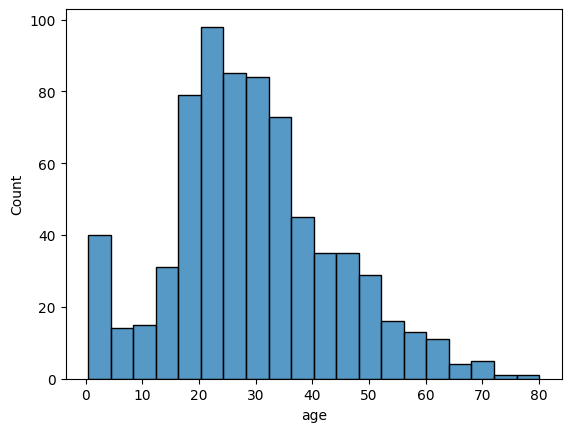

In [11]:
sns.histplot(df["age"])

<Axes: xlabel='age_mean', ylabel='Count'>

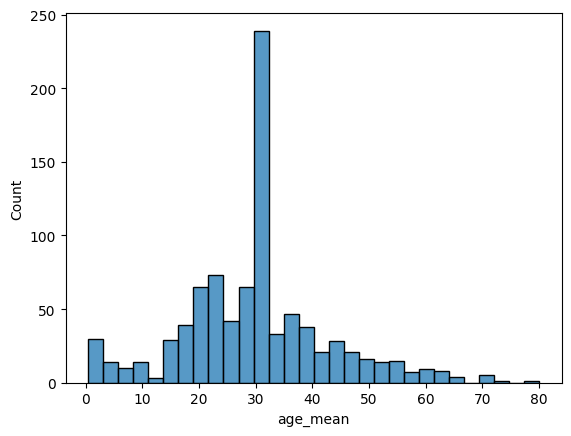

In [12]:
sns.histplot(df["age_mean"])

In [14]:
# if data is skewed then we can use median imputation
df["age_median"] = df["age"].fillna(df["age"].median())
df[["age", "age_median"]].head(10)

,age,age_median
0,22.0,22.0
1,38.0,38.0
2,26.0,26.0
3,35.0,35.0
4,35.0,35.0
5,NaN,28.0
6,54.0,54.0
7,2.0,2.0
8,27.0,27.0
9,14.0,14.0


### mode imputation technique - categorical data

In [16]:
df[df['embarked'].isnull()]

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,age_mean,age_median
61,1,1,female,38.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,38.0,38.0
829,1,1,female,62.0,0,0,80.0,NaN,First,woman,False,B,NaN,yes,True,62.0,62.0


In [18]:
df.embarked.unique()

array(['S', 'C', 'Q', nan], dtype=object)

In [23]:
embarked_mode = df[df["embarked"].notna()]['embarked'].mode()[0]
embarked_mode

'S'

In [24]:
df["embarked"].fillna(embarked_mode, inplace=True)

In [29]:
df.embarked.isnull().sum()

np.int64(0)